**Dataset:** `DataFiles/data_cleaning.csv`  
**Random State:** 12 | **Test Size:** 20% | **Threshold:** 0.6

In [1]:
# ═══════════════════════════════════════════════════════════════
# CELL 1 — Import Library
# ═══════════════════════════════════════════════════════════════
import os
import pickle
import time
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import shap

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve,
    precision_recall_curve, confusion_matrix, average_precision_score
)

print('✅ Library berhasil di-import')

✅ Library berhasil di-import


In [2]:
# ═══════════════════════════════════════════════════════════════
# CELL 2 — Konfigurasi Global
# ═══════════════════════════════════════════════════════════════
RANDOM_STATE = 12
TEST_SIZE    = 0.2
THRESHOLD    = 0.6   # threshold klasifikasi phishing
TARGET_COL   = 'label'

BASE_DIR  = os.getcwd()
DATA_PATH = os.path.join(BASE_DIR, 'DataFiles', 'data_cleaning.csv')

# 37 Fitur URL-based
URL_FEATURES_37 = [
    'length_url', 'length_hostname', 'ip', 'nb_dots', 'nb_hyphens',
    'nb_at', 'nb_qm', 'nb_and', 'nb_eq', 'nb_underscore', 'nb_tilde',
    'nb_percent', 'nb_slash', 'nb_star', 'nb_colon', 'nb_comma',
    'nb_semicolumn', 'nb_dollar', 'nb_space', 'nb_www', 'nb_com',
    'nb_dslash', 'http_in_path', 'https_token', 'ratio_digits_url',
    'ratio_digits_host', 'punycode', 'port', 'tld_in_path',
    'tld_in_subdomain', 'abnormal_subdomain', 'nb_subdomains',
    'prefix_suffix', 'random_domain', 'shortening_service',
    'path_extension', 'nb_redirection'
]

print(f'Base dir  : {BASE_DIR}')
print(f'Data path : {DATA_PATH}')
print(f'Random state: {RANDOM_STATE} | Test size: {TEST_SIZE} | Threshold: {THRESHOLD}')
print(f'URL features (37): {len(URL_FEATURES_37)} fitur')

Base dir  : d:\TUGAS AKHIR\Phishing-Website-Detection-using-XGBoost-and-RFM
Data path : d:\TUGAS AKHIR\Phishing-Website-Detection-using-XGBoost-and-RFM\DataFiles\data_cleaning.csv
Random state: 12 | Test size: 0.2 | Threshold: 0.6
URL features (37): 37 fitur


## 1. Data & Fitur

In [3]:
# ═══════════════════════════════════════════════════════════════
# CELL 3 — Load Dataset & Eksplorasi
# ═══════════════════════════════════════════════════════════════
df = pd.read_csv(DATA_PATH)
df.columns = df.columns.str.strip()

print('=== Info Dataset ===')
print(f'Shape       : {df.shape[0]} baris × {df.shape[1]} kolom')
print(f'Duplikat    : {df.duplicated().sum()}')
print(f'Missing vals: {df.isnull().sum().sum()}')
print()

# Distribusi label
label_counts = df[TARGET_COL].value_counts()
print('=== Distribusi Label ===')
print(f'Benign   (0): {label_counts.get(0, 0):,} ({label_counts.get(0,0)/len(df)*100:.1f}%)')
print(f'Phishing (1): {label_counts.get(1, 0):,} ({label_counts.get(1,0)/len(df)*100:.1f}%)')
print()

# Tampilkan sample
display(df.head(3))

=== Info Dataset ===
Shape       : 11429 baris × 83 kolom
Duplikat    : 0
Missing vals: 0

=== Distribusi Label ===
Benign   (0): 5,715 (50.0%)
Phishing (1): 5,714 (50.0%)



,url,length_url,length_hostname,ip,nb_dots,nb_hyphens,nb_at,nb_qm,nb_and,nb_eq,...,domain_in_title,domain_with_copyright,whois_registered_domain,domain_registration_length,domain_age,web_traffic,dns_record,google_index,page_rank,label
0,http://www.crestonwood.com/router.php,37,19,0,3,0,0,0,0,0,...,0,1,0,45,-1,0,1,1,4,0
1,http://shadetreetechnology.com/V4/validation/a...,77,23,1,1,0,0,0,0,0,...,1,0,0,77,5767,0,0,1,2,1
2,https://support-appleld.com.secureupdate.duila...,126,50,1,4,1,0,1,2,3,...,1,0,0,14,4004,5828815,0,1,0,1


In [4]:
# ═══════════════════════════════════════════════════════════════
# CELL 4 — Definisi Fitur & Pembagian Data (Train/Test)
# ═══════════════════════════════════════════════════════════════
id_cols   = [c for c in ['url'] if c in df.columns]
all_feats = [c for c in df.columns if c not in [TARGET_COL] + id_cols]

# Pisahkan fitur URL-based dan web-content
web_feats_44    = [c for c in all_feats if c not in URL_FEATURES_37]
hybrid_feats_81 = URL_FEATURES_37 + web_feats_44

print(f'Fitur URL-based (37)  : {len(URL_FEATURES_37)} fitur')
print(f'Fitur Web-content (44): {len(web_feats_44)} fitur')
print(f'Fitur Hybrid (81)     : {len(hybrid_feats_81)} fitur')

# Label
y_all = pd.to_numeric(df[TARGET_COL], errors='coerce')
df    = df.loc[y_all.notna()].copy()
y_all = y_all.loc[y_all.notna()].astype('int64')

# Train/Test Split
train_idx, test_idx = train_test_split(
    df.index, test_size=TEST_SIZE, stratify=y_all, random_state=RANDOM_STATE
)

def make_xy(feats):
    avail = [c for c in feats if c in df.columns]
    X_tr = df.loc[train_idx, avail].apply(pd.to_numeric, errors='coerce').dropna()
    X_te = df.loc[test_idx,  avail].apply(pd.to_numeric, errors='coerce').dropna()
    y_tr = y_all.loc[X_tr.index]
    y_te = y_all.loc[X_te.index]
    return X_tr, X_te, y_tr, y_te

X_train_37, X_test_37, y_train_37, y_test_37 = make_xy(URL_FEATURES_37)
X_train_81, X_test_81, y_train_81, y_test_81 = make_xy(hybrid_feats_81)

print(f'\nMode 37 → Train: {X_train_37.shape}, Test: {X_test_37.shape}')
print(f'Mode 81 → Train: {X_train_81.shape}, Test: {X_test_81.shape}')

Fitur URL-based (37)  : 37 fitur
Fitur Web-content (44): 44 fitur
Fitur Hybrid (81)     : 81 fitur

Mode 37 → Train: (9143, 37), Test: (2286, 37)
Mode 81 → Train: (9143, 81), Test: (2286, 81)


## 2. Load Model dari PKL

Model telah dilatih sebelumnya menggunakan **Genetic Algorithm (GA) Tuning** (16 populasi, 8 generasi, 5-Fold CV) dan disimpan sebagai file `.pkl`. Model dimuat dari disk tanpa perlu training ulang.

In [5]:
# ═══════════════════════════════════════════════════════════════
# CELL 5 — Load Model dari PKL
# ═══════════════════════════════════════════════════════════════
import json

def load_pkl(filename):
    path = os.path.join(BASE_DIR, filename)
    with open(path, 'rb') as f:
        return pickle.load(f)

def load_cols(filename):
    path = os.path.join(BASE_DIR, filename)
    with open(path, encoding='utf-8') as f:
        return [l.strip() for l in f if l.strip()]

def patch_lr(model):
    """Patch kompatibilitas sklearn >= 1.6: tambahkan multi_class jika tidak ada."""
    if not hasattr(model, 'multi_class'):
        model.multi_class = 'auto'
    return model

# Mode 37 fitur
rf37    = load_pkl('random_forest_model_37.pkl')
xgb37   = load_pkl('xgboost_model_37.pkl')
lr37    = patch_lr(load_pkl('rule_lr_37.pkl'))
cols37  = [c for c in load_cols('feature_columns_37.txt') if c in X_test_37.columns]
X_te37  = X_test_37[cols37]

# Mode 81 fitur
rf81    = load_pkl('random_forest_model_81.pkl')
xgb81   = load_pkl('xgboost_model_81.pkl')
lr81    = patch_lr(load_pkl('rule_lr_81.pkl'))
cols81  = [c for c in load_cols('feature_columns_81.txt') if c in X_test_81.columns]
X_te81  = X_test_81[cols81]

# Tampilkan hyperparameter terbaik dari GA
with open('ga_tuning_report_37.json') as f: report37 = json.load(f)
with open('ga_tuning_report_81.json') as f: report81 = json.load(f)

print('=== Hyperparameter Terbaik GA (Mode 37 Fitur) ===')
print(f"RF  best CV F1: {report37['ga']['rf_best_cv_f1']:.4f}")
print(f"XGB best CV F1: {report37['ga']['xgb_best_cv_f1']:.4f}")
print()
print('=== Hyperparameter Terbaik GA (Mode 81 Fitur) ===')
print(f"RF  best CV F1: {report81['ga']['rf_best_cv_f1']:.4f}")
print(f"XGB best CV F1: {report81['ga']['xgb_best_cv_f1']:.4f}")
print()

# Tabel hyperparameter RF dan XGB mode 81
rf_params  = {k:v for k,v in report81['ga']['rf_best_params'].items() if k not in ['random_state','n_jobs']}
xgb_params = {k:v for k,v in report81['ga']['xgb_best_params'].items() if k not in ['random_state','n_jobs','eval_metric']}

print('--- Hyperparameter RF (Mode 81) ---')
display(pd.DataFrame(rf_params.items(), columns=['Hyperparameter','Nilai Optimal']))

print('--- Hyperparameter XGBoost (Mode 81) ---')
display(pd.DataFrame(xgb_params.items(), columns=['Hyperparameter','Nilai Optimal']))

print('\n✅ Semua model berhasil di-load')

=== Hyperparameter Terbaik GA (Mode 37 Fitur) ===
RF  best CV F1: 0.8736
XGB best CV F1: 0.8800

=== Hyperparameter Terbaik GA (Mode 81 Fitur) ===
RF  best CV F1: 0.9638
XGB best CV F1: 0.9666

--- Hyperparameter RF (Mode 81) ---


,Hyperparameter,Nilai Optimal
0,n_estimators,464
1,max_depth,14
2,min_samples_split,4
3,min_samples_leaf,1
4,max_features,log2


--- Hyperparameter XGBoost (Mode 81) ---


,Hyperparameter,Nilai Optimal
0,n_estimators,372.000000
1,learning_rate,0.126585
2,max_depth,5.000000
3,subsample,0.761040
4,colsample_bytree,0.711330
5,min_child_weight,3.867081
6,gamma,0.451126
7,reg_alpha,0.664309
8,reg_lambda,2.270156



✅ Semua model berhasil di-load


## 3. Evaluasi Model

Evaluasi dilakukan pada **data test (20%)** yang tidak digunakan saat training.  
**Threshold prediksi: 0.6** (jika P(phishing) ≥ 0.6 → diklasifikasikan phishing).

In [6]:
# ═══════════════════════════════════════════════════════════════
# CELL 6 — Fungsi Evaluasi
# ═══════════════════════════════════════════════════════════════
def evaluate_model(name, y_true, y_pred, y_prob):
    """Hitung semua metrik dari prediksi dan probabilitas."""
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()
    return {
        'Model'    : name,
        'Accuracy' : accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall'   : recall_score(y_true, y_pred, zero_division=0),
        'F1-Score' : f1_score(y_true, y_pred, zero_division=0),
        'AUC-ROC'  : roc_auc_score(y_true, y_prob),
        'TP': int(tp), 'TN': int(tn), 'FP': int(fp), 'FN': int(fn),
        '_prob': y_prob,
        '_pred': y_pred,
        '_cm'  : confusion_matrix(y_true, y_pred, labels=[0,1])
    }

def predict_with_threshold(model, X, threshold=THRESHOLD):
    """Prediksi dengan threshold custom."""
    prob = model.predict_proba(X)[:, 1]
    pred = (prob >= threshold).astype(int)
    return pred, prob

def stacking_predict(lr_model, rf_model, xgb_model, X, threshold=THRESHOLD):
    """Rekonstruksi prediksi stacking: RF prob + XGB prob → LR meta-learner."""
    rf_p  = rf_model.predict_proba(X)[:, 1]
    xgb_p = xgb_model.predict_proba(X)[:, 1]
    n_in  = int(getattr(lr_model, 'n_features_in_', 2))
    meta  = np.column_stack([rf_p, xgb_p])[:, :n_in]
    prob  = lr_model.predict_proba(meta)[:, 1]
    pred  = (prob >= threshold).astype(int)
    return pred, prob

def display_cm(cm, title):
    """Tampilkan confusion matrix sebagai DataFrame."""
    df_cm = pd.DataFrame(
        cm,
        index=['Aktual Benign (0)', 'Aktual Phishing (1)'],
        columns=['Prediksi Benign (0)', 'Prediksi Phishing (1)']
    )
    print(f'\n🧩 Confusion Matrix — {title}')
    display(df_cm)

print('✅ Fungsi evaluasi siap')

✅ Fungsi evaluasi siap


In [7]:
# ═══════════════════════════════════════════════════════════════
# CELL 7 — Evaluasi Model: Mode 37 Fitur (URL-based)
# ═══════════════════════════════════════════════════════════════
print('='*60)
print('  MODE 37 FITUR (URL-based)')
print('='*60)

y37 = y_test_37.loc[X_te37.index]

# RF-37
rf_pred37,  rf_prob37  = predict_with_threshold(rf37,  X_te37)
# XGB-37
xgb_pred37, xgb_prob37 = predict_with_threshold(xgb37, X_te37)
# Stacking-37
stk_pred37, stk_prob37 = stacking_predict(lr37, rf37, xgb37, X_te37)

results_37 = [
    evaluate_model('RF-37',    y37, rf_pred37,  rf_prob37),
    evaluate_model('XGB-37',   y37, xgb_pred37, xgb_prob37),
    evaluate_model('Stack-37', y37, stk_pred37, stk_prob37),
]

cols_show = ['Model','Accuracy','Precision','Recall','F1-Score','AUC-ROC','TP','TN','FP','FN']
df_res37 = pd.DataFrame([{k:v for k,v in r.items() if not k.startswith('_')} for r in results_37])
for c in ['Accuracy','Precision','Recall','F1-Score','AUC-ROC']:
    df_res37[c] = df_res37[c].map('{:.4f}'.format)

print('\n📊 Hasil Evaluasi Mode 37 Fitur:')
display(df_res37[cols_show])

for r in results_37:
    display_cm(r['_cm'], r['Model'])

  MODE 37 FITUR (URL-based)

📊 Hasil Evaluasi Mode 37 Fitur:


,Model,Accuracy,Precision,Recall,F1-Score,AUC-ROC,TP,TN,FP,FN
0,RF-37,0.8920,0.9125,0.8670,0.8892,0.9579,991,1048,95,152
1,XGB-37,0.8963,0.9187,0.8696,0.8935,0.9647,994,1055,88,149
2,Stack-37,0.9007,0.9111,0.8880,0.8994,0.9646,1015,1044,99,128



🧩 Confusion Matrix — RF-37


,Prediksi Benign (0),Prediksi Phishing (1)
Aktual Benign (0),1048,95
Aktual Phishing (1),152,991



🧩 Confusion Matrix — XGB-37


,Prediksi Benign (0),Prediksi Phishing (1)
Aktual Benign (0),1055,88
Aktual Phishing (1),149,994



🧩 Confusion Matrix — Stack-37


,Prediksi Benign (0),Prediksi Phishing (1)
Aktual Benign (0),1044,99
Aktual Phishing (1),128,1015


In [8]:
# ═══════════════════════════════════════════════════════════════
# CELL 8 — Evaluasi Model: Mode 81 Fitur (Hybrid)
# ═══════════════════════════════════════════════════════════════
print('='*60)
print('  MODE 81 FITUR (Hybrid)')
print('='*60)

y81 = y_test_81.loc[X_te81.index]

# RF-81
rf_pred81,  rf_prob81  = predict_with_threshold(rf81,  X_te81)
# XGB-81
xgb_pred81, xgb_prob81 = predict_with_threshold(xgb81, X_te81)
# Stacking-81
stk_pred81, stk_prob81 = stacking_predict(lr81, rf81, xgb81, X_te81)

results_81 = [
    evaluate_model('RF-81',    y81, rf_pred81,  rf_prob81),
    evaluate_model('XGB-81',   y81, xgb_pred81, xgb_prob81),
    evaluate_model('Stack-81', y81, stk_pred81, stk_prob81),
]

df_res81 = pd.DataFrame([{k:v for k,v in r.items() if not k.startswith('_')} for r in results_81])
for c in ['Accuracy','Precision','Recall','F1-Score','AUC-ROC']:
    df_res81[c] = df_res81[c].map('{:.4f}'.format)

print('\n📊 Hasil Evaluasi Mode 81 Fitur:')
display(df_res81[cols_show])

for r in results_81:
    display_cm(r['_cm'], r['Model'])

  MODE 81 FITUR (Hybrid)

📊 Hasil Evaluasi Mode 81 Fitur:


,Model,Accuracy,Precision,Recall,F1-Score,AUC-ROC,TP,TN,FP,FN
0,RF-81,0.9654,0.9828,0.9475,0.9648,0.9954,1083,1124,19,60
1,XGB-81,0.9764,0.9781,0.9746,0.9763,0.9969,1114,1118,25,29
2,Stack-81,0.9751,0.9772,0.9729,0.9750,0.9963,1112,1117,26,31



🧩 Confusion Matrix — RF-81


,Prediksi Benign (0),Prediksi Phishing (1)
Aktual Benign (0),1124,19
Aktual Phishing (1),60,1083



🧩 Confusion Matrix — XGB-81


,Prediksi Benign (0),Prediksi Phishing (1)
Aktual Benign (0),1118,25
Aktual Phishing (1),29,1114



🧩 Confusion Matrix — Stack-81


,Prediksi Benign (0),Prediksi Phishing (1)
Aktual Benign (0),1117,26
Aktual Phishing (1),31,1112


## 4. Rule-Based Filtering & Hybrid


In [9]:
# ═══════════════════════════════════════════════════════════════
# CELL 9 — Fungsi Rule-Based (Vectorized)
# ═══════════════════════════════════════════════════════════════
def rule_flag(X_df):
    """Terapkan rule-based secara vectorized. Return array 0/1."""
    def col(name, default=0):
        return X_df[name].fillna(default).values if name in X_df.columns else np.full(len(X_df), default)

    # Very Important: salah satu saja → langsung Phishing
    vi = (
        (col('suspicious_tld') == 1) |
        (col('nb_at')          >= 1) |
        (col('ip')             == 1) |
        (col('nb_underscore')  >  3)
    )

    # Important (skor ×2)
    imp = (
        (col('ratio_digits_url') >  0.3).astype(int) +
        (col('nb_subdomains')    >  3  ).astype(int) +
        (col('nb_percent')       >  5  ).astype(int) +
        (col('nb_tilde')         >= 1  ).astype(int) +
        (col('nb_semicolumn')    >= 1  ).astype(int) +
        (col('nb_star')          >= 1  ).astype(int) +
        (col('nb_comma')         >= 1  ).astype(int) +
        (col('random_domain')    == 1  ).astype(int)
    )

    # Less Important (skor ×1)
    less = (
        (col('length_hostname')    >  30).astype(int) +
        (col('nb_dollar')          >= 1 ).astype(int) +
        (col('nb_qm')              >  2 ).astype(int) +
        (col('nb_colon')           >  1 ).astype(int) +
        (col('nb_eq')              >  8 ).astype(int) +
        (col('nb_dots')            >  4 ).astype(int) +
        (col('nb_slash')           >  7 ).astype(int) +
        (col('nb_and')             >  3 ).astype(int) +
        (col('nb_hyphens')         >  3 ).astype(int) +
        (col('http_in_path')       == 1 ).astype(int) +
        (col('https_token')        == 1 ).astype(int) +
        (col('port')               == 1 ).astype(int) +
        (col('shortening_service') == 1 ).astype(int)
    )

    risk_score = 2 * imp + less
    return (vi | (risk_score >= 5)).astype(int)

print('✅ Fungsi rule-based siap')

✅ Fungsi rule-based siap


In [10]:
# ═══════════════════════════════════════════════════════════════
# CELL 10 — Evaluasi Hybrid (Rule-Based + Stacking)
# ═══════════════════════════════════════════════════════════════
def hybrid_predict(X_df, stack_prob, threshold=THRESHOLD):
    """Hybrid: jika rule tangkap → naikkan prob ke ≥0.95, else pakai stack_prob."""
    rule  = rule_flag(X_df)
    hyb_p = np.where(rule == 1, np.maximum(stack_prob, 0.95), stack_prob)
    hyb_d = (hyb_p >= threshold).astype(int)
    n_rule = int(rule.sum())
    return hyb_d, hyb_p, n_rule

# ── Mode 37 ──
hyb_pred37, hyb_prob37, n_rule37 = hybrid_predict(X_te37, stk_prob37)
res_hyb37 = evaluate_model('Hybrid-37', y37, hyb_pred37, hyb_prob37)

# ── Mode 81 ──
hyb_pred81, hyb_prob81, n_rule81 = hybrid_predict(X_te81, stk_prob81)
res_hyb81 = evaluate_model('Hybrid-81', y81, hyb_pred81, hyb_prob81)

# Tambahkan ke results
results_37.append(res_hyb37)
results_81.append(res_hyb81)

print('=== Hasil Evaluasi Hybrid ===')
df_hyb = pd.DataFrame([
    {k:v for k,v in r.items() if not k.startswith('_')}
    for r in [res_hyb37, res_hyb81]
])
for c in ['Accuracy','Precision','Recall','F1-Score','AUC-ROC']:
    df_hyb[c] = df_hyb[c].map('{:.4f}'.format)
display(df_hyb[cols_show])

print(f'\nURL ditangkap rule (Mode 37): {n_rule37} dari {len(X_te37)} ({n_rule37/len(X_te37)*100:.1f}%)')
print(f'URL ditangkap rule (Mode 81): {n_rule81} dari {len(X_te81)} ({n_rule81/len(X_te81)*100:.1f}%)')

display_cm(res_hyb37['_cm'], 'Hybrid-37')
display_cm(res_hyb81['_cm'], 'Hybrid-81')

=== Hasil Evaluasi Hybrid ===


,Model,Accuracy,Precision,Recall,F1-Score,AUC-ROC,TP,TN,FP,FN
0,Hybrid-37,0.8836,0.8783,0.8906,0.8844,0.9442,1018,1002,141,125
1,Hybrid-81,0.9528,0.9345,0.9738,0.9537,0.9922,1113,1065,78,30



URL ditangkap rule (Mode 37): 392 dari 2286 (17.1%)
URL ditangkap rule (Mode 81): 424 dari 2286 (18.5%)

🧩 Confusion Matrix — Hybrid-37


,Prediksi Benign (0),Prediksi Phishing (1)
Aktual Benign (0),1002,141
Aktual Phishing (1),125,1018



🧩 Confusion Matrix — Hybrid-81


,Prediksi Benign (0),Prediksi Phishing (1)
Aktual Benign (0),1065,78
Aktual Phishing (1),30,1113


## 5. Analisis Latency

Mengukur performa **kecepatan** 4 model/eksperimen pada:
- **Batch throughput**: berapa URL per detik (5 run, rata-rata)
- **Latency per-URL**: waktu prediksi untuk 1 URL (20 run, rata-rata)

In [11]:
# ═══════════════════════════════════════════════════════════════
# CELL 11 — Benchmark Latency (4 Eksperimen, Mode 81)
# ═══════════════════════════════════════════════════════════════
N_BATCH   = 5   # run untuk batch throughput
N_LATENCY = 20  # run untuk latency per-URL
X_single  = X_te81.iloc[[0]]

def predict_rf(X):
    p = rf81.predict_proba(X)[:, 1]
    return (p >= THRESHOLD).astype(int), p

def predict_xgb(X):
    p = xgb81.predict_proba(X)[:, 1]
    return (p >= THRESHOLD).astype(int), p

def predict_stacking(X):
    rf_p  = rf81.predict_proba(X)[:, 1]
    xgb_p = xgb81.predict_proba(X)[:, 1]
    meta  = np.column_stack([rf_p, xgb_p])[:, :2]
    p     = lr81.predict_proba(meta)[:, 1]
    return (p >= THRESHOLD).astype(int), p

def predict_hybrid(X):
    _, stk_p = predict_stacking(X)
    d, p, _  = hybrid_predict(X, stk_p)
    return d, p

experiments = [
    ('Random Forest (81)',    predict_rf),
    ('XGBoost (81)',          predict_xgb),
    ('Stacking RF+XGB (81)', predict_stacking),
    ('Hybrid Rule+Stack (81)', predict_hybrid),
]

batch_rows   = []
latency_rows = []

for name, fn in experiments:
    # Batch throughput
    times = []
    for _ in range(N_BATCH):
        t0 = time.perf_counter()
        fn(X_te81)
        times.append(time.perf_counter() - t0)
    avg_batch = np.mean(times)
    batch_rows.append({
        'Model'             : name,
        'Batch Time (s)'    : round(avg_batch, 4),
        'Throughput (URL/s)': round(len(X_te81) / avg_batch, 1),
    })

    # Latency per-URL
    times = []
    for _ in range(N_LATENCY):
        t0 = time.perf_counter()
        fn(X_single)
        times.append(time.perf_counter() - t0)
    latency_rows.append({
        'Model'       : name,
        'Avg (ms)'    : round(np.mean(times) * 1000, 3),
        'Min (ms)'    : round(np.min(times)  * 1000, 3),
        'Max (ms)'    : round(np.max(times)  * 1000, 3),
        'Std (ms)'    : round(np.std(times)  * 1000, 3),
    })

print('📊 Batch Throughput (seluruh data test)')
display(pd.DataFrame(batch_rows))

print('\n⚡ Latency Per-URL (1 URL)')
display(pd.DataFrame(latency_rows))

📊 Batch Throughput (seluruh data test)


,Model,Batch Time (s),Throughput (URL/s)
0,Random Forest (81),0.2324,9837.4
1,XGBoost (81),0.0389,58814.4
2,Stacking RF+XGB (81),0.2611,8756.4
3,Hybrid Rule+Stack (81),0.2525,9052.0



⚡ Latency Per-URL (1 URL)


,Model,Avg (ms),Min (ms),Max (ms),Std (ms)
0,Random Forest (81),103.323,90.185,157.129,21.002
1,XGBoost (81),45.431,36.752,67.733,10.793
2,Stacking RF+XGB (81),146.322,139.318,151.795,3.347
3,Hybrid Rule+Stack (81),143.498,134.877,153.102,5.474


## 6. SHAP Analysis


SHAP values shape: (2286, 81)
Fitur: 81



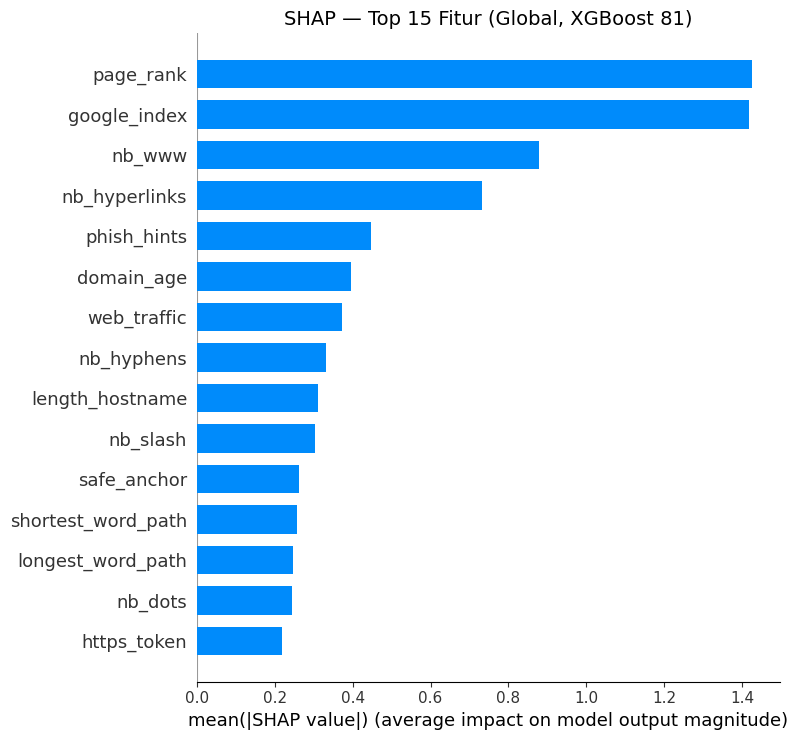

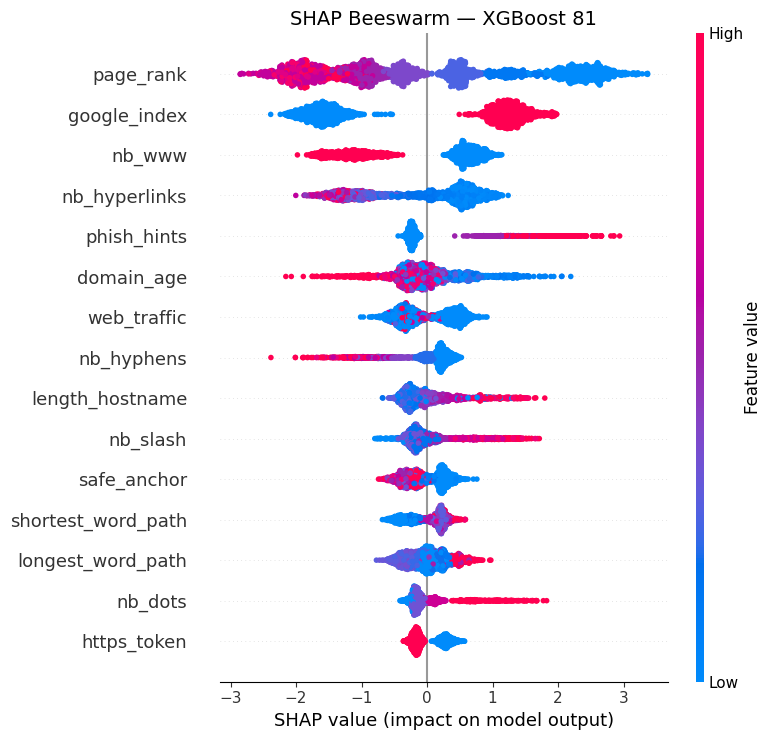

In [12]:
# ═══════════════════════════════════════════════════════════════
# CELL 12 — SHAP Global: XGBoost Mode 81
# ═══════════════════════════════════════════════════════════════
explainer    = shap.TreeExplainer(xgb81)
shap_values  = explainer.shap_values(X_te81)

print(f'SHAP values shape: {shap_values.shape}')
print(f'Fitur: {X_te81.shape[1]}')
print()

# Global Bar Chart
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_te81, plot_type='bar', max_display=15, show=False)
plt.title('SHAP — Top 15 Fitur (Global, XGBoost 81)', fontsize=14)
plt.tight_layout()
plt.show()

# Beeswarm
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_te81, max_display=15, show=False)
plt.title('SHAP Beeswarm — XGBoost 81', fontsize=14)
plt.tight_layout()
plt.show()


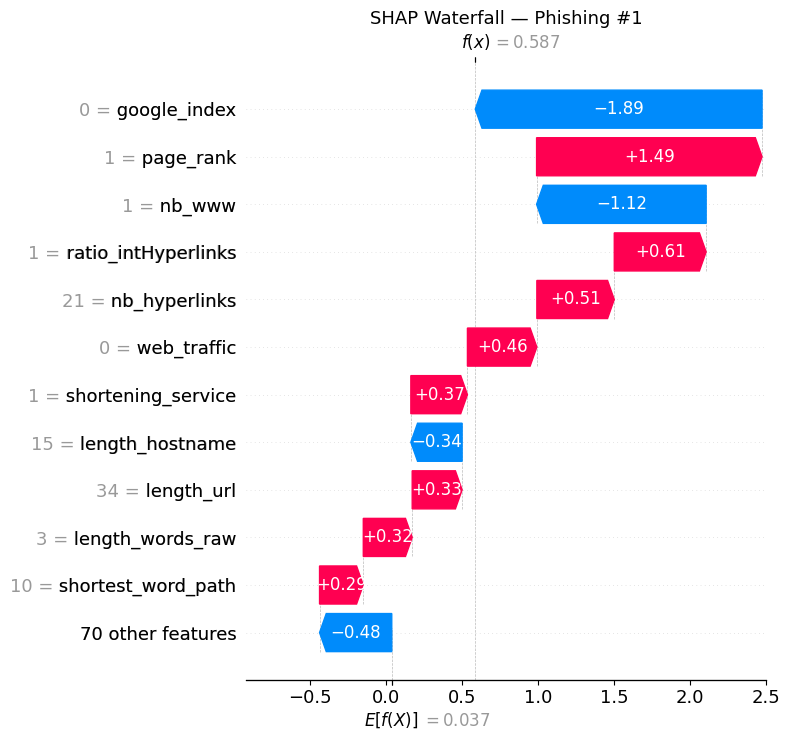

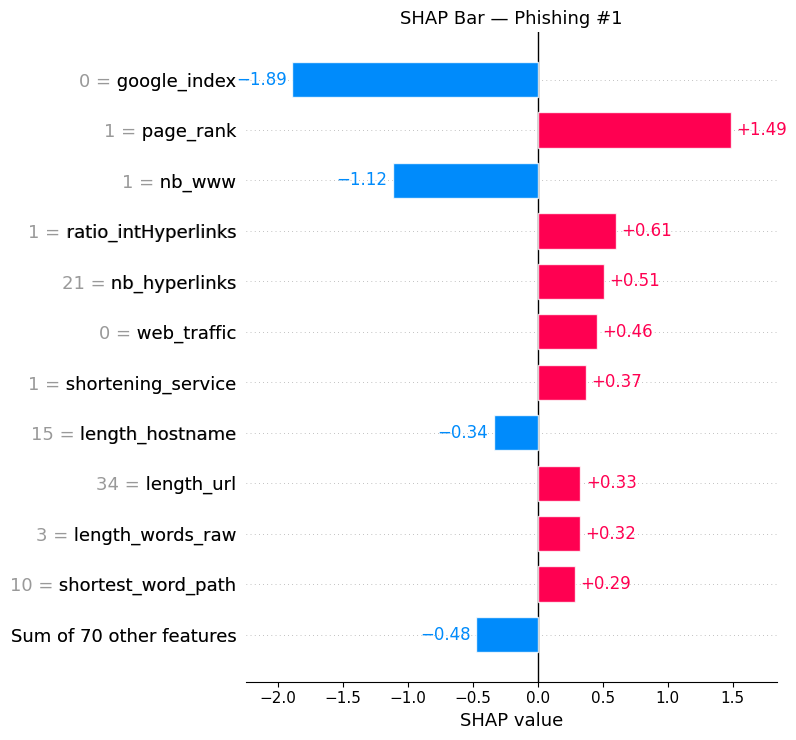

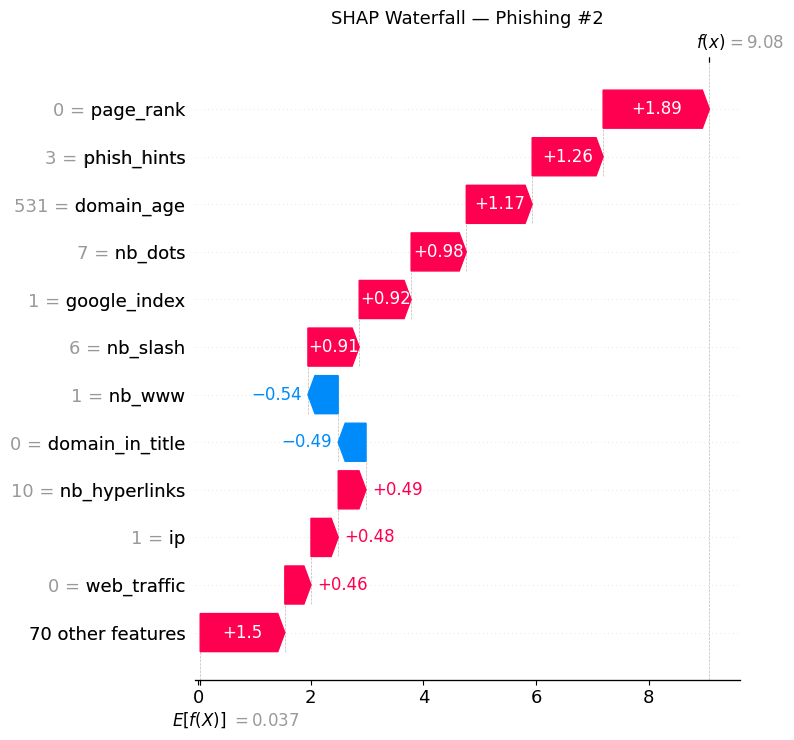

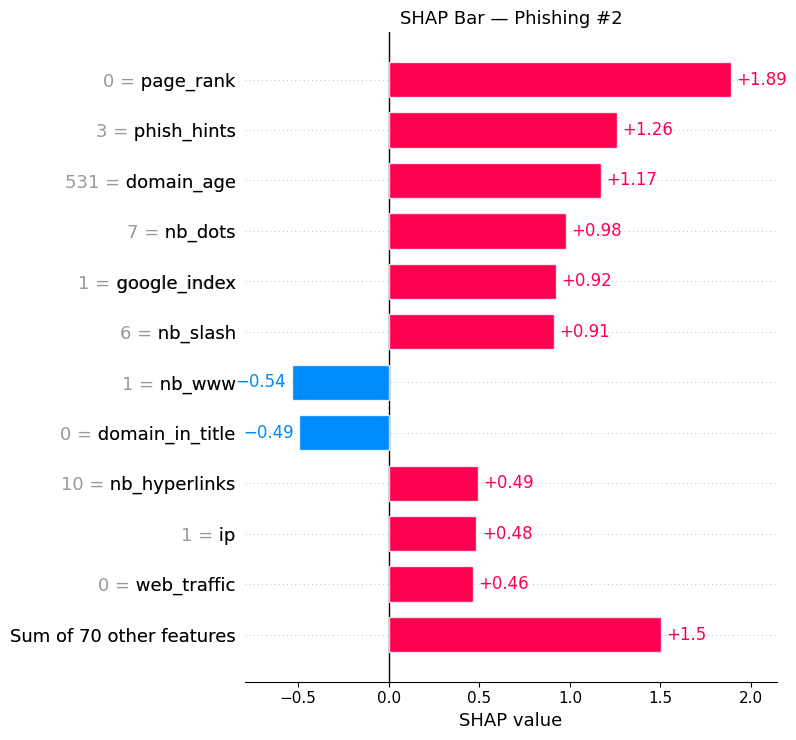

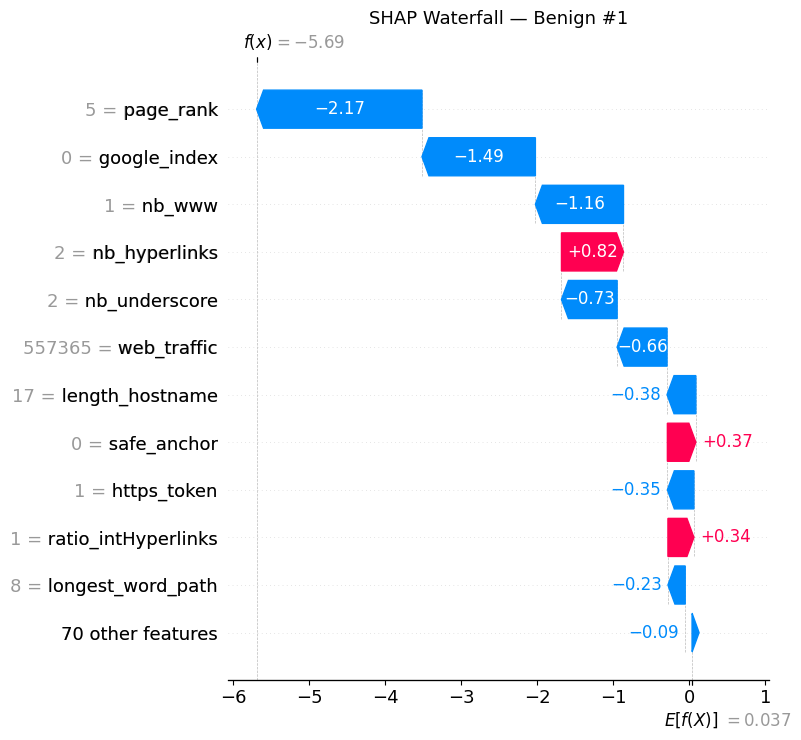

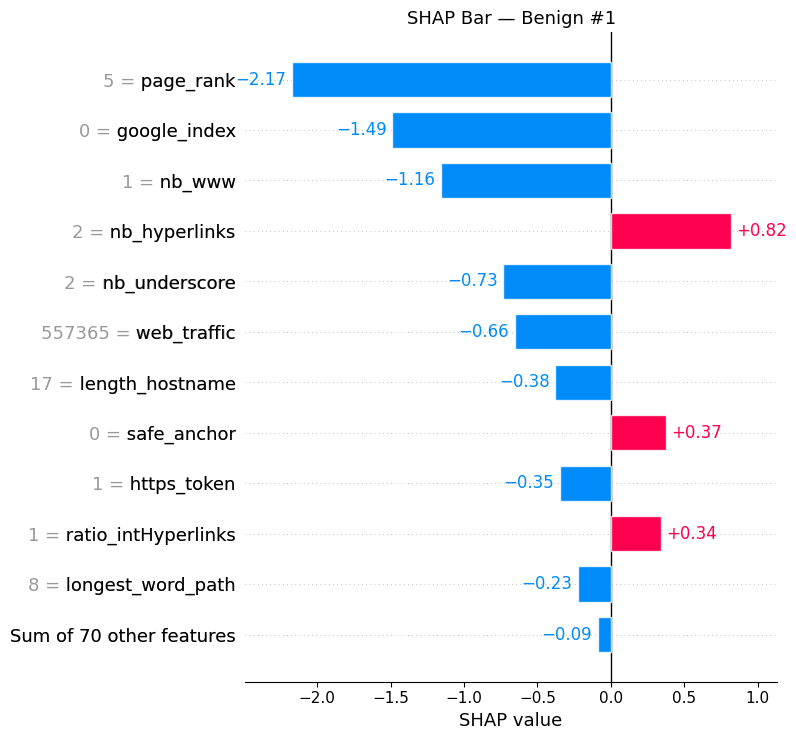

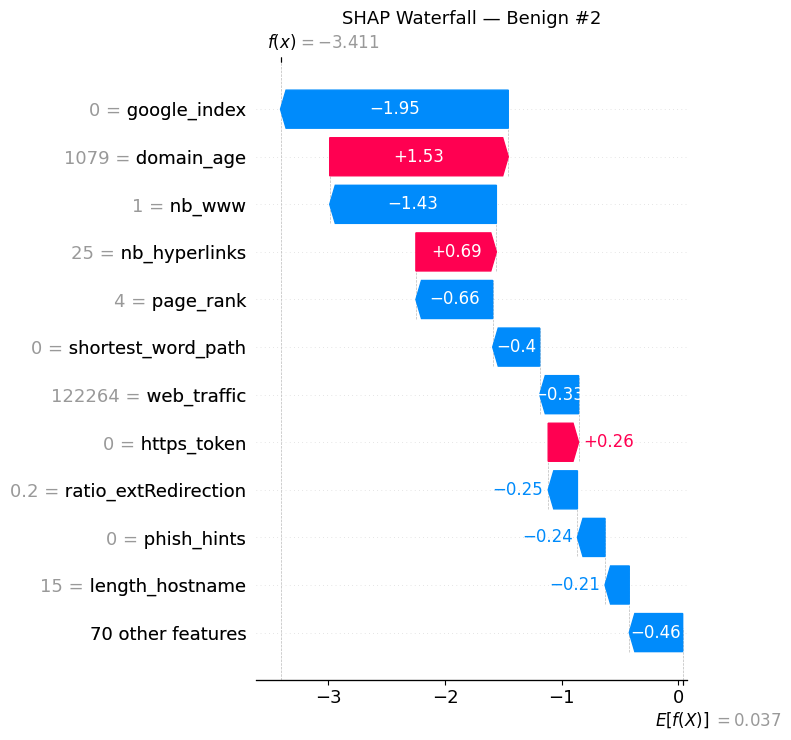

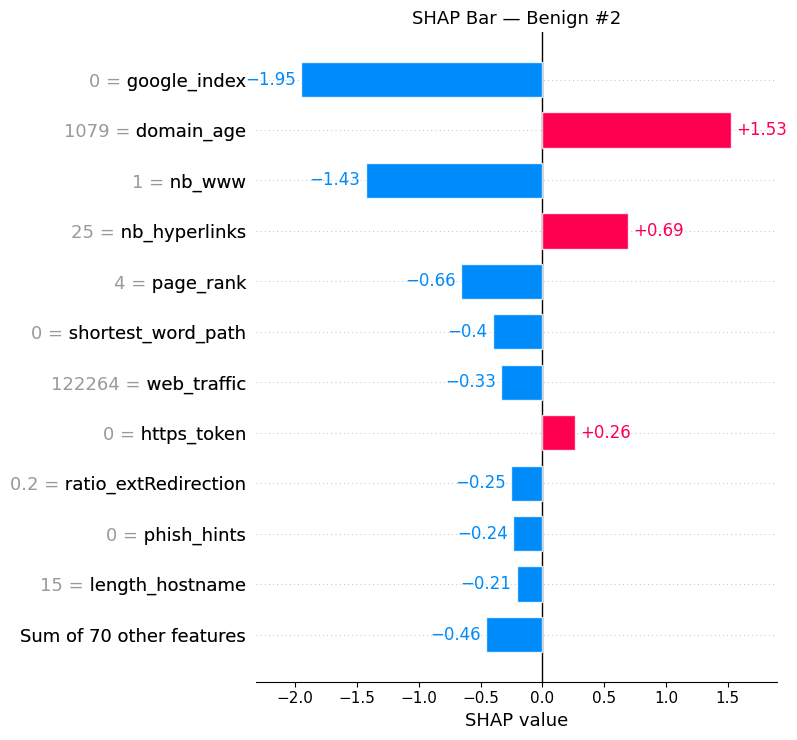

In [13]:
# ═══════════════════════════════════════════════════════════════
# CELL 13 — SHAP Lokal: 4 Contoh URL
# ═══════════════════════════════════════════════════════════════
# Pilih 2 phishing & 2 benign dari prediksi yang BENAR
correct_phishing = X_te81[
    (xgb_pred81 == 1) & (y81.values == 1)
].index
correct_benign = X_te81[
    (xgb_pred81 == 0) & (y81.values == 0)
].index

sample_idx = list(correct_phishing[:2]) + list(correct_benign[:2])
labels_map = {correct_phishing[0]: 'Phishing #1', correct_phishing[1]: 'Phishing #2',
              correct_benign[0]: 'Benign #1',   correct_benign[1]: 'Benign #2'}

for i, idx in enumerate(sample_idx, 1):
    row_pos  = X_te81.index.get_loc(idx)
    shap_exp = shap.Explanation(
        values    = shap_values[row_pos],
        base_values = explainer.expected_value,
        data      = X_te81.iloc[row_pos].values,
        feature_names = X_te81.columns.tolist()
    )
    label = labels_map[idx]

    # Waterfall
    plt.figure(figsize=(10, 6))
    shap.waterfall_plot(shap_exp, max_display=12, show=False)
    plt.title(f'SHAP Waterfall — {label}', fontsize=13)
    plt.tight_layout()
    plt.show()
    
    # Signed Bar
    plt.figure(figsize=(10, 6))
    shap.plots.bar(shap_exp, max_display=12, show=False)
    plt.title(f'SHAP Bar — {label}', fontsize=13)
    plt.tight_layout()
    plt.show()

## 7. Perbandingan Model

In [14]:
# ═══════════════════════════════════════════════════════════════
# CELL 14 — Tabel Perbandingan Lengkap
# ═══════════════════════════════════════════════════════════════
all_results = results_37 + results_81

df_all = pd.DataFrame([
    {k:v for k,v in r.items() if not k.startswith('_')}
    for r in all_results
])

# Format persen
for c in ['Accuracy','Precision','Recall','F1-Score','AUC-ROC']:
    df_all[c] = (df_all[c] * 100).round(2).astype(str) + '%'

print('📊 Perbandingan Semua Model (Threshold = 0.6):')
display(df_all[cols_show])

📊 Perbandingan Semua Model (Threshold = 0.6):


,Model,Accuracy,Precision,Recall,F1-Score,AUC-ROC,TP,TN,FP,FN
0,RF-37,89.2%,91.25%,86.7%,88.92%,95.79%,991,1048,95,152
1,XGB-37,89.63%,91.87%,86.96%,89.35%,96.47%,994,1055,88,149
2,Stack-37,90.07%,91.11%,88.8%,89.94%,96.46%,1015,1044,99,128
3,Hybrid-37,88.36%,87.83%,89.06%,88.44%,94.42%,1018,1002,141,125
4,RF-81,96.54%,98.28%,94.75%,96.48%,99.54%,1083,1124,19,60
5,XGB-81,97.64%,97.81%,97.46%,97.63%,99.69%,1114,1118,25,29
6,Stack-81,97.51%,97.72%,97.29%,97.5%,99.63%,1112,1117,26,31
7,Hybrid-81,95.28%,93.45%,97.38%,95.37%,99.22%,1113,1065,78,30


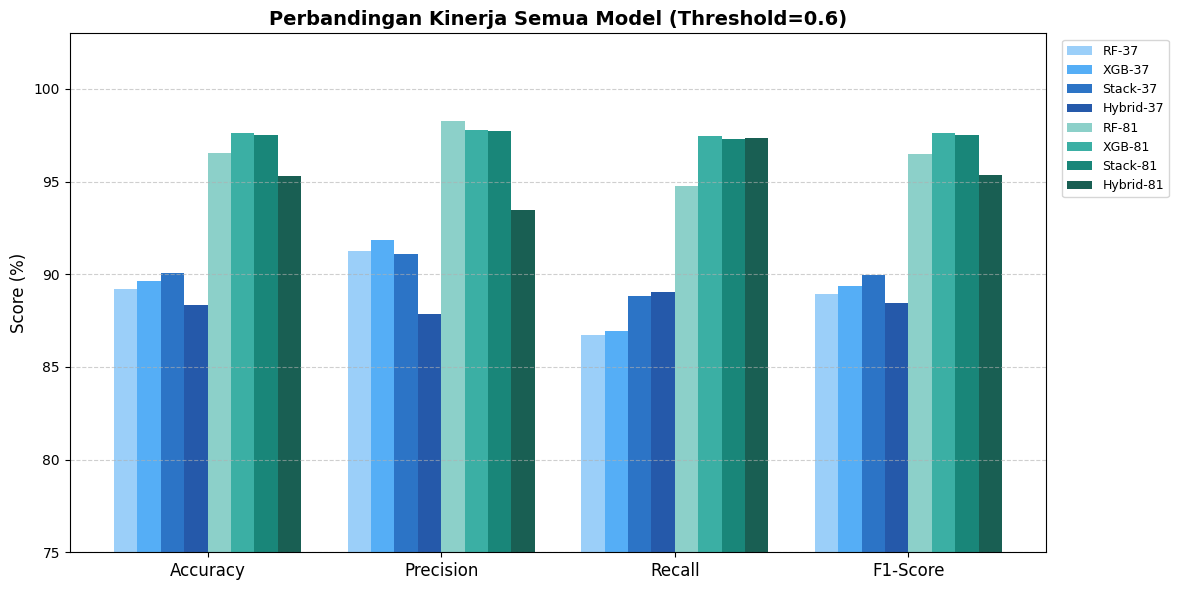

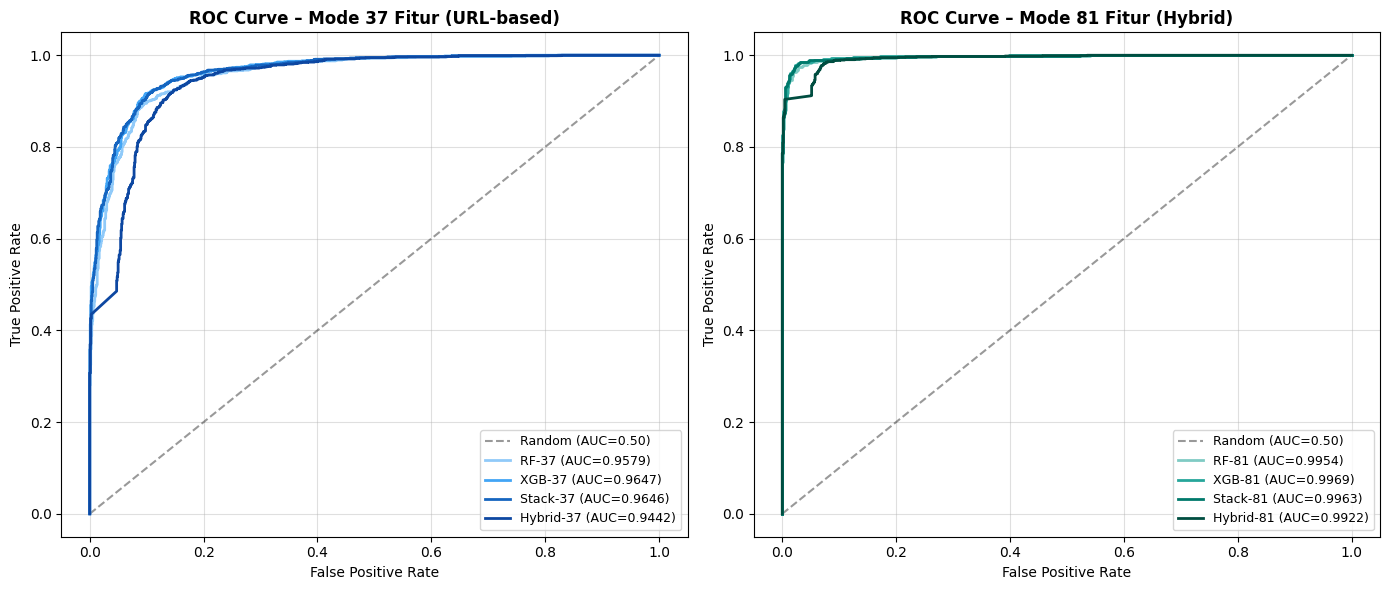

✅ Visualisasi tersimpan di folder results/


In [15]:
# ═══════════════════════════════════════════════════════════════
# CELL 15 — Visualisasi Perbandingan
# ═══════════════════════════════════════════════════════════════
COLORS_MAP = {
    'RF-37'      : '#90CAF9', 'XGB-37'    : '#42A5F5',
    'Stack-37'   : '#1565C0', 'Hybrid-37' : '#0D47A1',
    'RF-81'      : '#80CBC4', 'XGB-81'    : '#26A69A',
    'Stack-81'   : '#00796B', 'Hybrid-81' : '#004D40',
}
all_results_raw = [
    {**{k:v for k,v in r.items() if not k.startswith('_')},
     'color': COLORS_MAP[r['Model']]}
    for r in all_results
]
df_raw = pd.DataFrame(all_results_raw)
metrics = ['Accuracy','Precision','Recall','F1-Score']

# ── Bar chart Acc/Prec/Rec/F1 ──
fig, ax = plt.subplots(figsize=(14, 6))
x     = np.arange(len(metrics))
n     = len(df_raw)
width = 0.10
for i, row in df_raw.iterrows():
    offset = (i - n/2 + 0.5) * width
    bars = ax.bar(x + offset, [row[m]*100 for m in metrics],
                  width, label=row['Model'], color=row['color'], alpha=0.9)
ax.set_xticks(x)
ax.set_xticklabels(['Accuracy','Precision','Recall','F1-Score'], fontsize=12)
ax.set_ylabel('Score (%)', fontsize=12)
ax.set_title('Perbandingan Kinerja Semua Model (Threshold=0.6)', fontsize=14, fontweight='bold')
ax.set_ylim(75, 103)
ax.yaxis.grid(True, linestyle='--', alpha=0.6)
ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1), fontsize=9)
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.savefig('results/01_metric_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# ── ROC Curve ──
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
groups = [
    ('Mode 37 Fitur (URL-based)', results_37),
    ('Mode 81 Fitur (Hybrid)',    results_81),
]
for ax, (title, rlist) in zip(axes, groups):
    ax.plot([0,1],[0,1],'k--',alpha=0.4, label='Random (AUC=0.50)')
    for r in rlist:
        fpr, tpr, _ = roc_curve(y37 if '37' in r['Model'] else y81, r['_prob'])
        ax.plot(fpr, tpr, color=COLORS_MAP[r['Model']], lw=2,
                label=f"{r['Model']} (AUC={r['AUC-ROC']:.4f})")
    ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
    ax.set_title(f'ROC Curve – {title}', fontweight='bold')
    ax.legend(fontsize=9); ax.grid(alpha=0.4)
plt.tight_layout()
plt.savefig('results/02_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print('✅ Visualisasi tersimpan di folder results/')